In [2]:
import pickle
from dython.nominal import associations
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
from numpy import load
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.utils import shuffle
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor

In [116]:
def open_pickles(model_name: str):
    if "cull" in model_name:
        suffixes = ["test_scores", "train_scores", "train_sizes", "test_scores_percent"]
    else:
        suffixes = ["test_scores", "train_scores", "train_sizes"]

    model_attrs = {}
    for i in suffixes:
        with open(f"20k_{model_name}_{i}.pickle", "rb") as fh:
            model_attrs[i] = pickle.load(fh)

    return model_attrs
    

In [139]:
def draw_learning_curve(model_name: str):
    model = open_pickles(model_name)
    plot_len = int(len(model['train_sizes'])*0.9)
    plt.plot(model['train_sizes'][:plot_len], model['train_scores'][:plot_len],label="train")
    plt.plot(model['train_sizes'][:plot_len], model['test_scores'][:plot_len],label="test")
    plt.legend(loc="best")
    plt.title(f"{model_name} learning curve")
    plt.ylim(0,70000)
    plt.xlabel("training data size")
    plt.ylabel("mean absolute error (kJmol$^{-1}$nm$^{-1}$)")
    plt.xticks([100000,200000,300000,400000])
    plt.savefig(f"{model_name}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

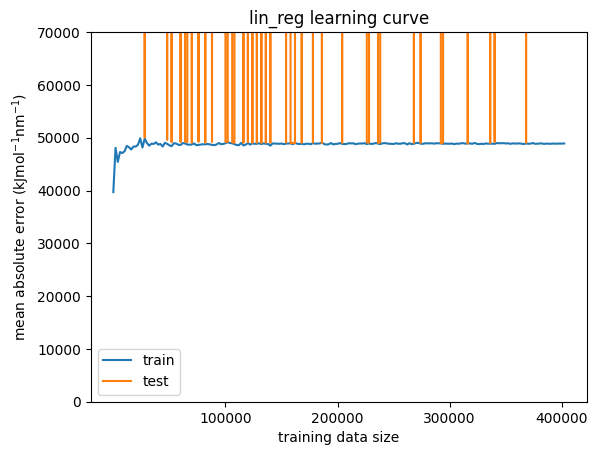

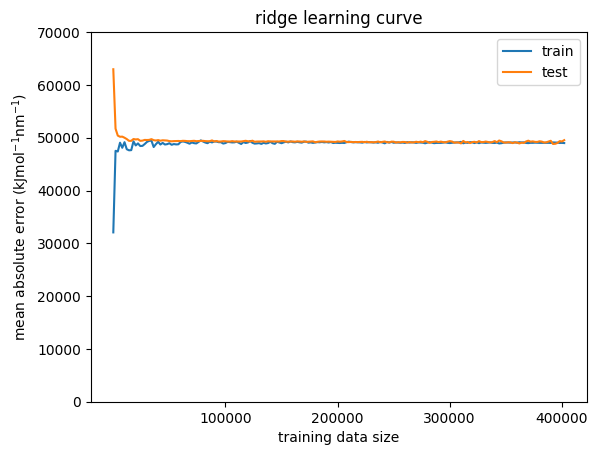

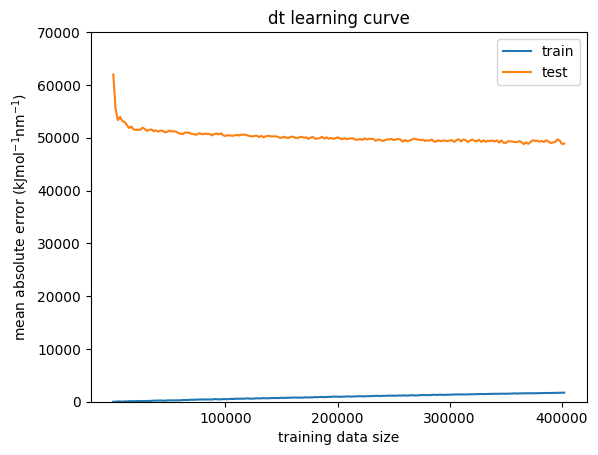

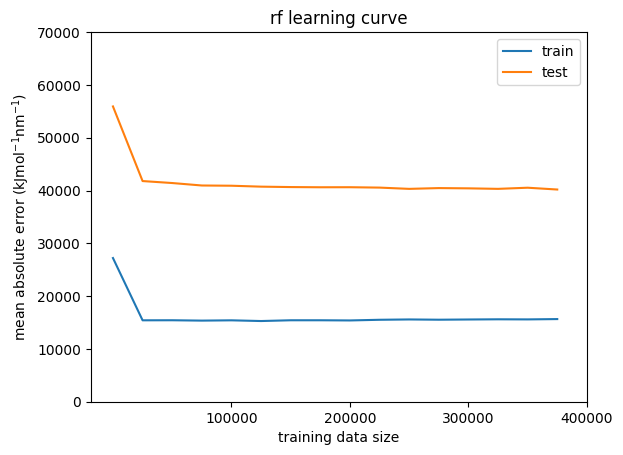

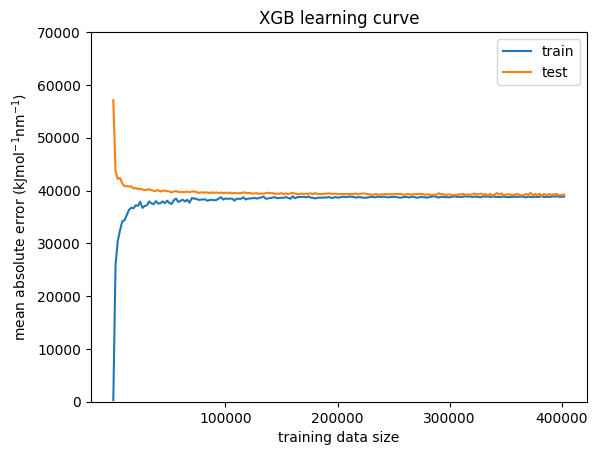

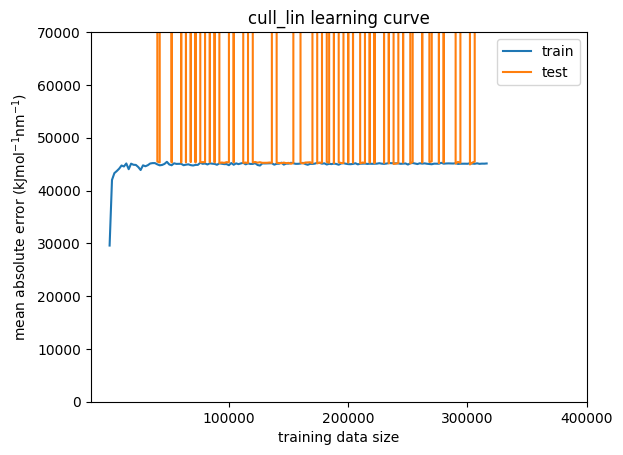

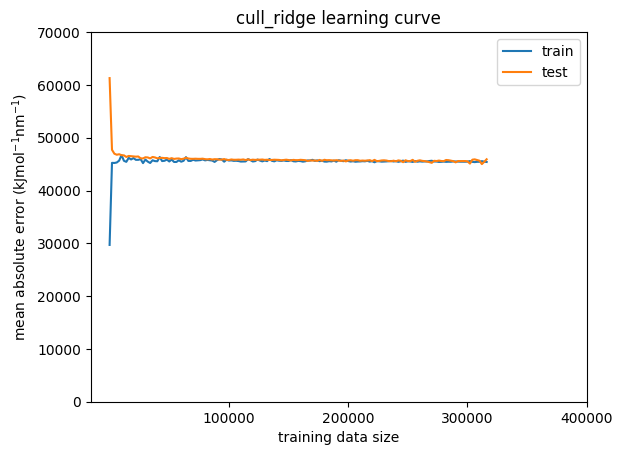

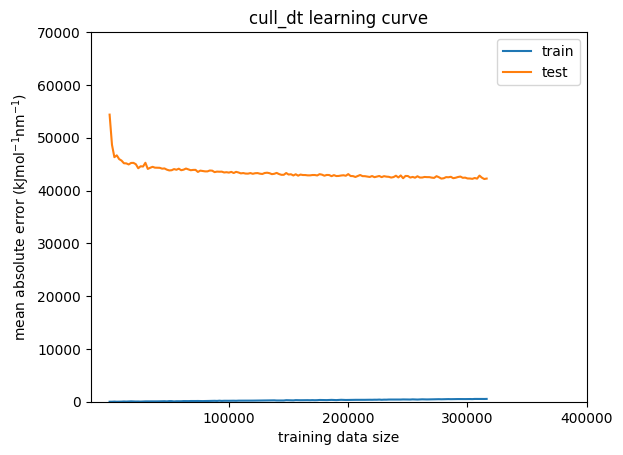

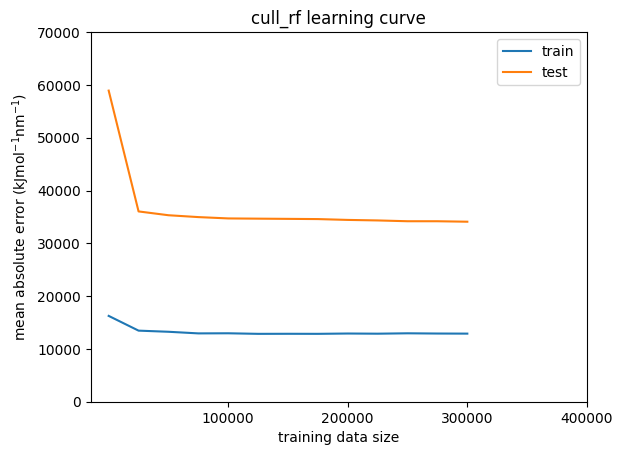

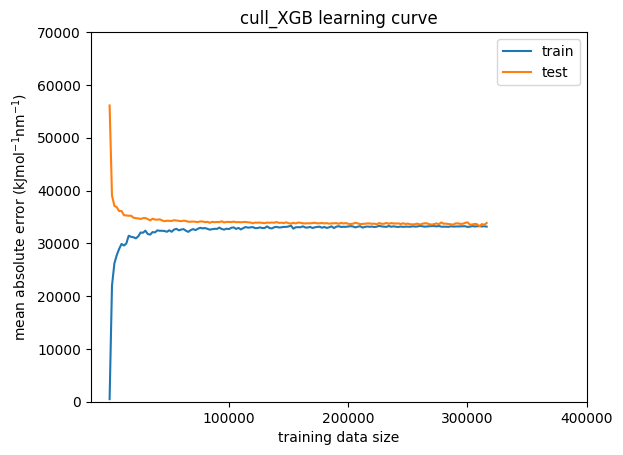

In [140]:
draw_learning_curve("lin_reg")
draw_learning_curve("ridge")
draw_learning_curve("dt")
draw_learning_curve("rf")
draw_learning_curve("XGB")
draw_learning_curve("cull_lin")
draw_learning_curve("cull_ridge")
draw_learning_curve("cull_dt")
draw_learning_curve("cull_rf")
draw_learning_curve("cull_XGB")



[57101.998265616916, 43624.63672796525, 42177.57223250395, 42396.83072860398, 41342.03052125293, 40812.75466686016, 40831.875217642126, 40769.04631844806, 40802.73546006324, 40381.28008306499, 40491.40091311058, 40247.94170723315, 40354.64602311212, 40179.64466615669, 40086.33479996288, 40146.58612654228, 40227.07390086709, 40095.68019403435, 39937.02623850792, 39933.35283674127, 40098.7310186761, 39793.512377970575, 39969.876564360675, 39969.73859293536, 39902.638727511934, 39817.64042693649, 39644.15153871634, 39829.27626711254, 39878.865208283336, 39718.79513621836, 39720.00915107162, 39720.85716909458, 39719.84717549778, 39782.53992155351, 39685.23324352362, 39819.155434744585, 39803.1446190439, 39722.96712679178, 39545.048853029395, 39659.330632465775, 39593.96171304988, 39658.14900865939, 39592.43952214758, 39536.630930963336, 39643.155488528275, 39563.773951315496, 39625.687221564265, 39543.348291789924, 39625.30806888181, 39515.45242898139, 39580.61829321874, 39553.19117765004,

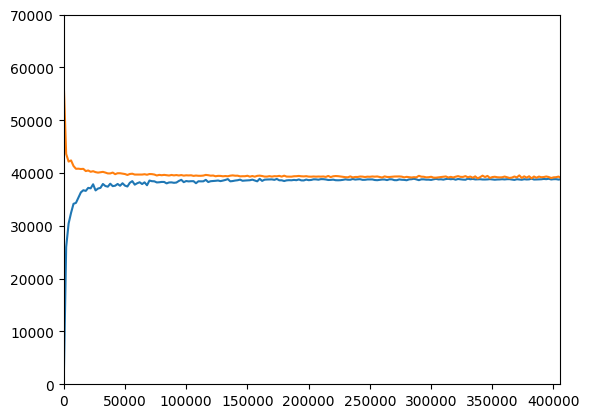

In [115]:
lin_reg_attrs = open_pickles("XGB")
plt.plot(lin_reg_attrs['train_sizes'], lin_reg_attrs['train_scores'])
plt.plot(lin_reg_attrs['train_sizes'], lin_reg_attrs['test_scores'])
plt.ylim(0, 70000)

print(lin_reg_attrs['test_scores'])
plt.savefig("XGB.pdf", format="pdf", bbox_inches="tight")

In [85]:
import statistics

[58923.11508896817, 36040.63000660871, 35319.42360903508, 34967.33451822391, 34714.612739729346, 34671.317109189695, 34631.521603048706, 34591.44144362847, 34433.21430059309, 34333.79889980417, 34182.9159583202, 34181.170132485306, 34093.00408779067, 33863.9361644547, 34081.43178980151]
0.18943206703912976


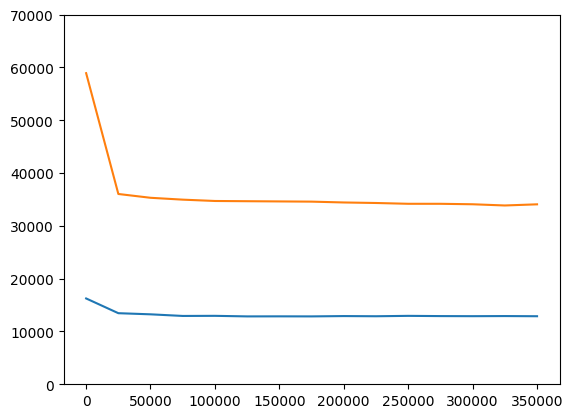

In [86]:
rf_reg_attrs = open_pickles("cull_rf")
plt.plot(rf_reg_attrs['train_sizes'], rf_reg_attrs['train_scores'])
plt.plot(rf_reg_attrs['train_sizes'], rf_reg_attrs['test_scores'])
plt.ylim(0, 70000)
print(rf_reg_attrs['test_scores'])
with open("20k_cull_rf_test_scores_percent.pickle", "rb") as fh:
    rf_reg_attrs['test_percents'] = pickle.load(fh)
print(statistics.mean(rf_reg_attrs['test_percents'][7:]))

34306.375148911655


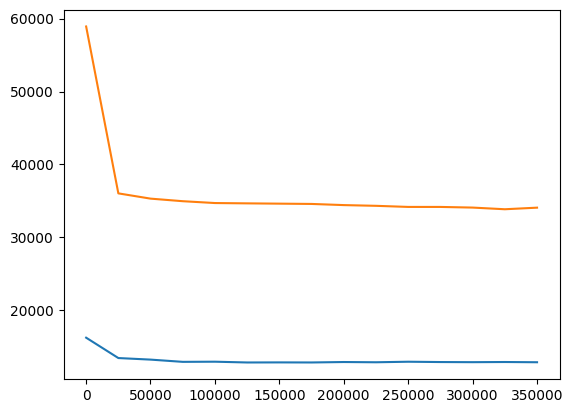

In [93]:
ridge_attrs = open_pickles("cull_rf")
plt.plot(ridge_attrs['train_sizes'], ridge_attrs['train_scores'])
plt.plot(ridge_attrs['train_sizes'], ridge_attrs['test_scores'])

print(statistics.mean(ridge_attrs['test_scores'][-10:]))

0.1789609877779367


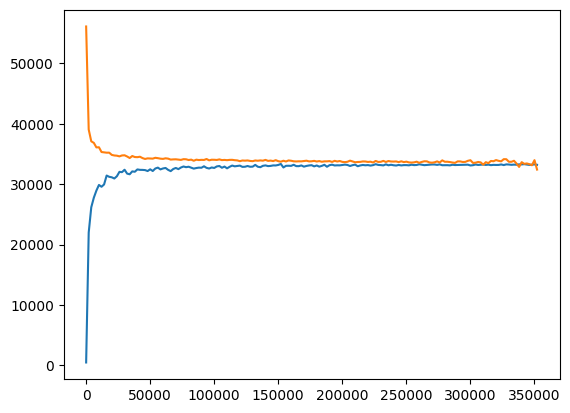

In [90]:
XGB_attrs = open_pickles("cull_XGB")
plt.plot(XGB_attrs['train_sizes'], XGB_attrs['train_scores'])
plt.plot(XGB_attrs['train_sizes'], XGB_attrs['test_scores'])
print(statistics.mean(XGB_attrs['test_scores_percent'][-10:]))

In [3]:
with open('X_cull_mean.pickle', 'rb') as handle:
    load_X = pickle.load(handle)

with open('Y_cull_mean.pickle', 'rb') as handle:
    load_Y = pickle.load(handle)

X = pd.DataFrame(load_X, columns=["i", "i_atom_num", "i_radius", "i_mass", "i_e_negat", "i_hybrid", "j", "j_atom_num", "j_radius", "j_mass", "j_e_negat", "j_hybrid", "R_ij", "bond_order", "1st_nei"])
y = pd.DataFrame(load_Y)



   i  i_atom_num  i_radius  i_mass  i_e_negat  i_hybrid  j  j_atom_num  \
0  C           6        70   12.00       2.55         4  C           6   
1  H           1        25    1.01       2.20         1  C           6   
2  C           6        70   12.00       2.55         4  C           6   
3  H           1        25    1.01       2.20         1  C           6   
4  C           6        70   12.00       2.55         4  H           1   

   j_radius  j_mass  j_e_negat  j_hybrid      R_ij  bond_order       1st_nei  
0        70   12.00       2.55         2  0.153283       1.014    [CCHH, CH]  
1        70   12.00       2.55         2  0.109630       0.943       [C, CH]  
2        70   12.00       2.55         4  0.153403       0.990  [CCHH, CCHO]  
3        70   12.00       2.55         4  0.109770       0.931     [C, CCHH]  
4        25    1.01       2.20         1  0.109785       0.924     [CCHH, C]  
   i  i_atom_num  i_radius  i_mass  i_e_negat  i_hybrid  j  j_atom_num  \
0  C   

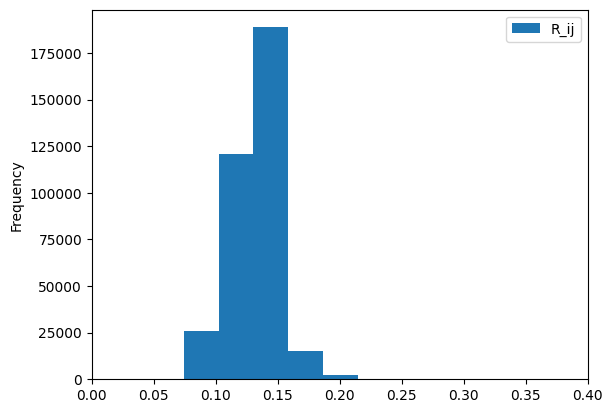

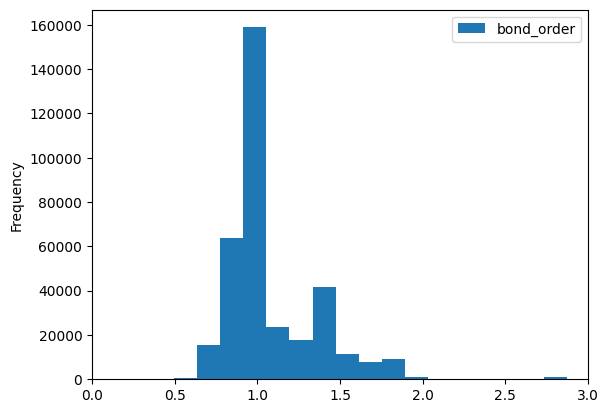

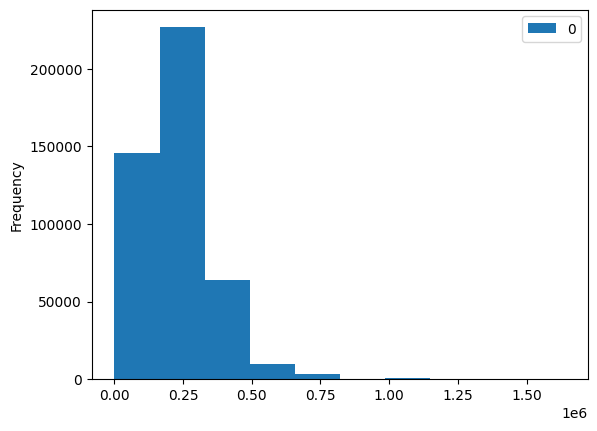

In [4]:
print(X.head())
X.plot.hist(column="R_ij", bins=5000, xlim=(0,0.4))
X.plot.hist(column="bond_order", bins=1000, xlim=(0, 3))
y.plot.hist()

print(X.head())
print(X.tail())

In [41]:
X[["i_nei", "j_nei"]] = X["1st_nei"].tolist()
X.drop(columns="1st_nei", inplace=True)

array(['C', 'H', 'O', 'N', 'S', 'CL', 'P', 'F', 'SI', 'BR', 'I', 'B',
       'SE'], dtype=object)

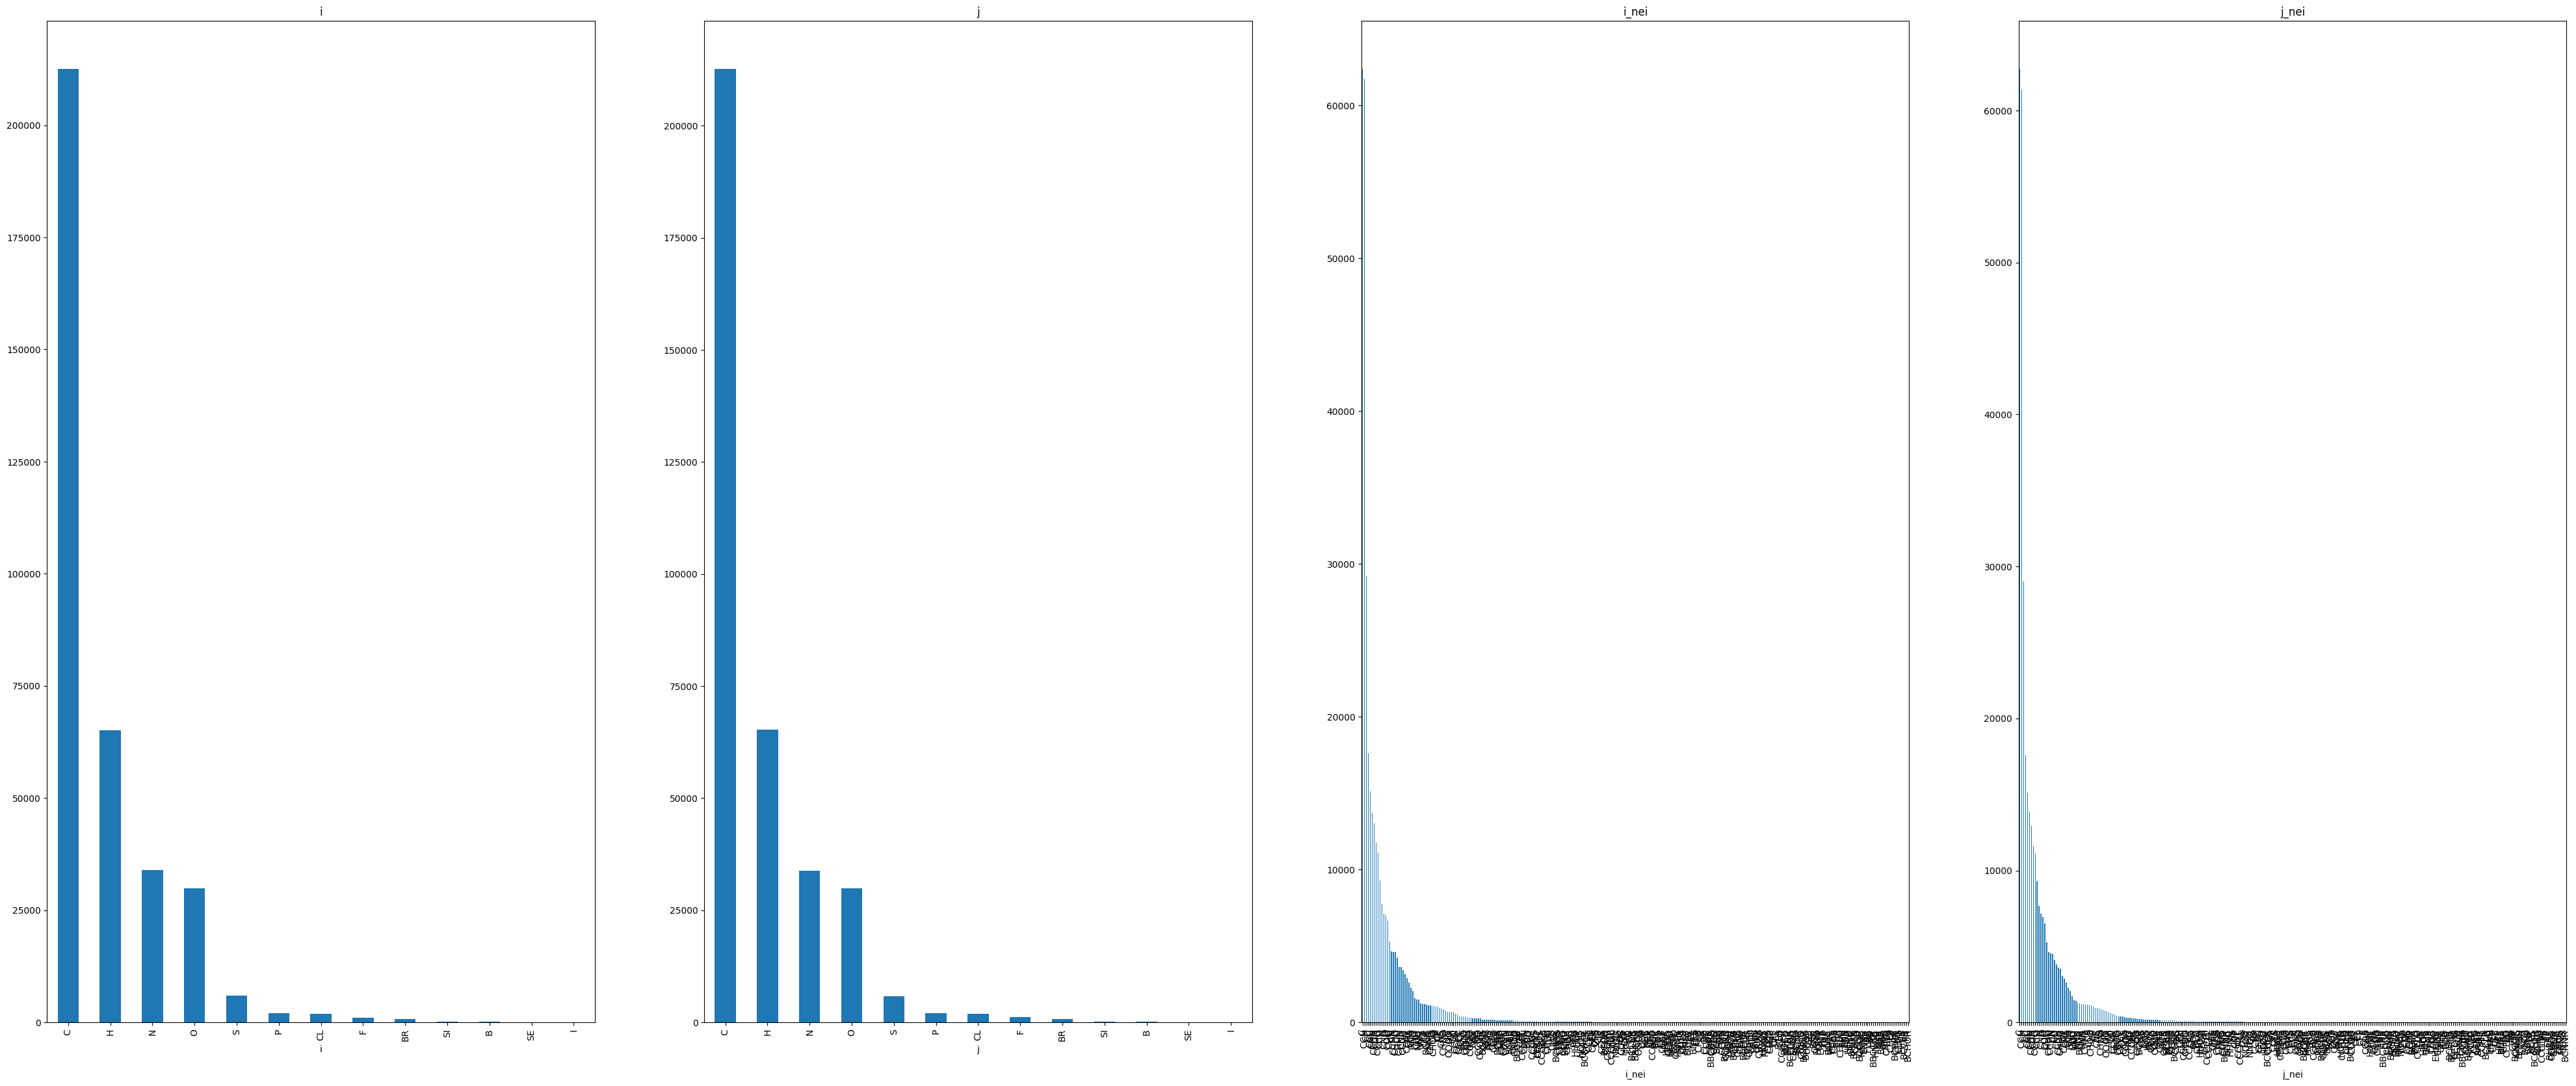

In [42]:
cat_features = ['i', 'j', 'i_nei', 'j_nei']
fig, ax = plt.subplots(1, len(cat_features), figsize=(50,20))

for i, cat_feature in enumerate(X[cat_features]):
    X[cat_feature].value_counts().plot(kind="bar",
                                          title=cat_feature, 
                                          ax=ax[i], )

X['i'].unique()

In [21]:
print(len(sorted(X['i'].unique())))
print(sorted(X['j'].unique()))

13
['B', 'BR', 'C', 'CL', 'F', 'H', 'I', 'N', 'O', 'P', 'S', 'SE', 'SI']


/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:321: RuntimeWarning: Rounded eta = 1.0000000000000002 to 1. This is probably due to floating point precision issues.
  warnings.warn(
/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:736: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[i], columns[j]] = _inf_nan_str(ij)
/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:737: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[j], columns[i]] = _inf_nan_str(ji)


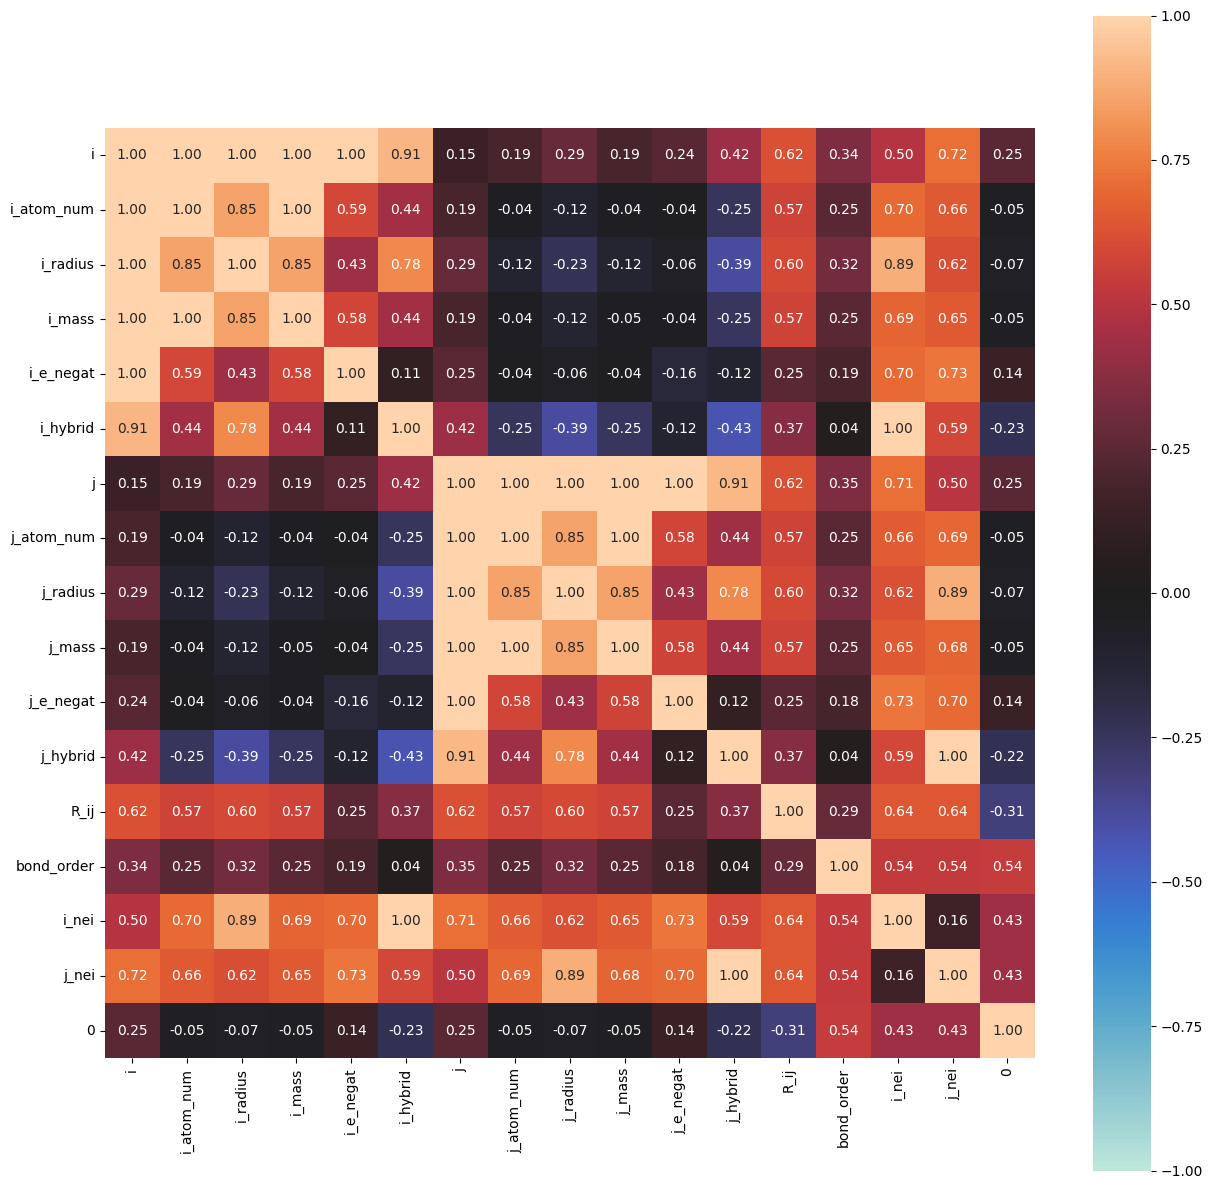

In [22]:
joint=X.join(y)
complete_correlation= associations(joint, figsize=(15,15))

In [43]:
def one_hot_encode_column(df: pd.DataFrame, col: int, pref: str = None) -> pd.DataFrame:
    encoded_column = pd.get_dummies(df[col], prefix=pref)
    df.drop(col, axis=1, inplace=True)
    # try:
    df = df.join(encoded_column)
    # except ValueError as verr:
    #     if "overlap" in verr.__str__():
    #         df = df.merge(encoded_column, left_on="BR", right_on="BR")

    return df

In [44]:
X = one_hot_encode_column(X, "i", "i")
X = one_hot_encode_column(X, "j", "j")
X = one_hot_encode_column(X, "i_nei", "i_nei")
X = one_hot_encode_column(X, "j_nei", "j_nei")


X.columns = X.columns.map(str)


In [45]:
print(X.head())
print(X.index)

   i_atom_num  i_radius  i_mass  i_e_negat  i_hybrid  j_atom_num  j_radius  \
0           6        70   12.00       2.55         4           6        70   
1           6        70   12.00       2.55         2           1        25   
2           6        70   12.00       2.55         4           6        70   
3           1        25    1.01       2.20         1           6        70   
4           1        25    1.01       2.20         1           6        70   

   j_mass  j_e_negat  j_hybrid  ...  j_nei_OOSS  j_nei_OP  j_nei_OS  \
0   12.00       2.55         2  ...       False     False     False   
1    1.01       2.20         1  ...       False     False     False   
2   12.00       2.55         4  ...       False     False     False   
3   12.00       2.55         4  ...       False     False     False   
4   12.00       2.55         4  ...       False     False     False   

   j_nei_OSS  j_nei_P  j_nei_PP  j_nei_PS  j_nei_S  j_nei_SS  j_nei_SSS  
0      False    False     Fals

In [46]:
y = y.loc[(y!=0).any(axis=1)]
y.tail()

,0
353869,132572.047193
353870,289038.061242
353871,135455.768604
353872,280136.223317
353873,438007.484510


<Axes: ylabel='Frequency'>

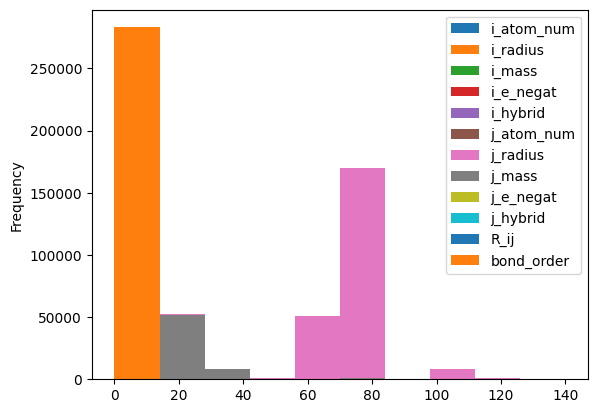

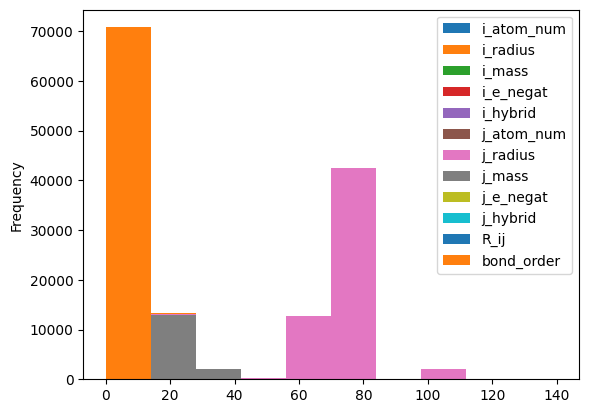

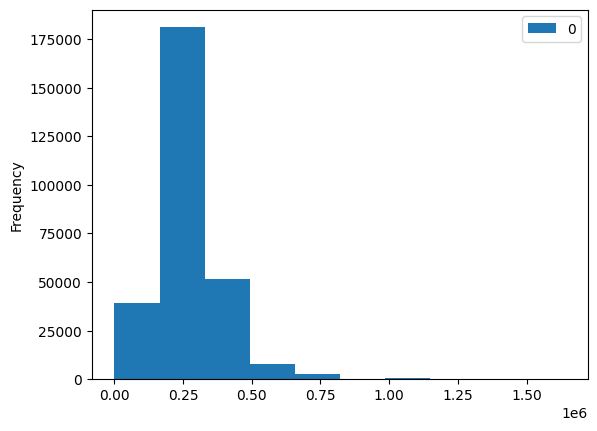

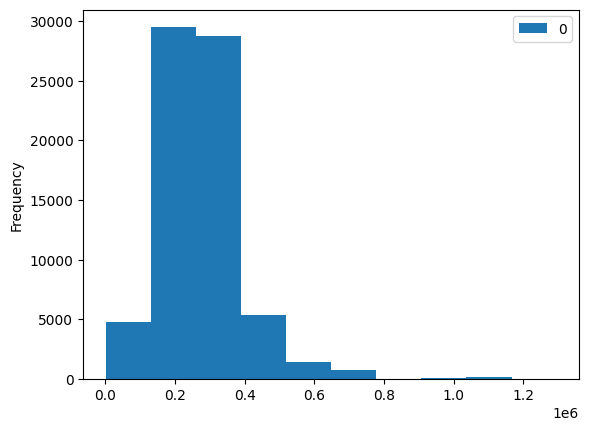

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)
X_train.plot.hist()
X_test.plot.hist()
y_train.plot.hist()
y_test.plot.hist()

In [ ]:
X_shuf, y_shuf = shuffle(X, y)
train_sizes = np.linspace(0.1, 1, 1000)
train_size_abs, train_scores, test_scores = learning_curve(LinearRegression(), X_shuf, y_shuf, shuffle = True, train_sizes=train_sizes, n_jobs=-1)

[0.63089973 0.62632573 0.62276518 0.61697615 0.61469218 0.61411801
 0.61284716 0.61379712 0.61460033 0.61080879 0.60962245 0.60480698
 0.60492716 0.59814232 0.59621776 0.60185082 0.6005485  0.60020847
 0.59332793 0.60164787 0.6005088  0.59924299 0.59879844 0.59767664
 0.59695467 0.59632582 0.59565356 0.59483943 0.59414601 0.59408074
 0.59473023 0.59495378 0.59549967 0.59546395 0.59455359 0.59445759
 0.59545131 0.59255933 0.58908694 0.59594358 0.59650066 0.59785373
 0.59645598 0.59525022 0.59541964 0.59564574 0.59557901 0.5951734
 0.59535288 0.59543514]
[-2.23636222e+20 -1.27605921e+20 -8.58659075e+19 -7.79852915e+18
 -2.54515887e+19 -1.02657524e+18 -7.20316853e+19 -6.56645548e+18
 -8.10453956e+17 -1.40827795e+18 -5.42222943e+18 -2.30363145e+19
 -1.45847723e+19 -2.55469172e+18 -3.90046197e+18 -3.01386778e+18
 -5.31341685e+18 -9.80885952e+18 -1.21328145e+19 -3.12302328e+17
 -2.05810188e+18 -2.42760364e+16 -6.48144554e+15 -1.07522448e+15
 -4.92898804e+17 -9.09442506e+17 -2.81281067e+14 -7

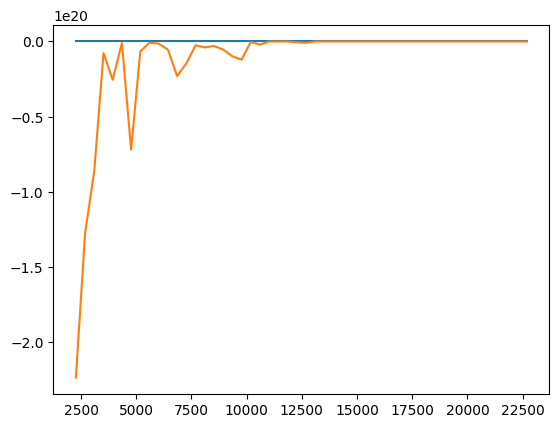

In [73]:
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)
plt.plot(train_size_abs, train_scores_mean)
plt.plot(train_size_abs, test_scores_mean)
print(train_scores_mean)
print(test_scores_mean)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

N = len(X)

#idx = 0

oddities = []
oddities_scores = []
test_scores = []
train_scores = []
test_scores = []
train_size = []
test_scores_percent = []
for i in range(5, N, 50):
    X_shuf, y_shuf = shuffle(X, y)
    #print(idx)
    Xnew_train = X_shuf[:i]
    ynew_train = y_shuf[:i]
    Xnew_test = X_shuf[i:]
    ynew_test = y_shuf[i:]
    # print(np.max(ynew_train))
    # ynew_test = y[i:]
    model = LinearRegression()
    reg = model.fit(Xnew_train, ynew_train)
    ytrain_predict = reg.predict(Xnew_train)
    ytest_predict = reg.predict(Xnew_test)
    #score_train = mean_squared_error(ynew_train, ytrain_predict)
    score_train = mean_absolute_error(ynew_train, ytrain_predict)
    score_test = mean_absolute_error(ynew_test, ytest_predict)
    score_test_percent = mean_absolute_percentage_error(ynew_test, ytest_predict)

    # train_scores.append(reg.score(Xnew_train, ynew_train))
    # test_scores.append(reg.score(Xnew_test, ynew_test))
    train_scores.append(score_train)
    test_scores.append(score_test)
    test_scores_percent.append(score_test_percent)
    train_size.append(i)
    #if i > 10000 and score_test < 0:
        #oddities.append(Xnew_test)
        #oddities_scores.append(score_test)
        
    #Xnew_train.plot.hist(bins=100)
    #Xnew_test.plot.hist(bins=100)
    #ynew_train.plot.hist(bins=50)
    #ynew_test.plot.hist(bins=50)
    #idx += 1


KeyboardInterrupt: 

In [74]:
#plt.plot(train_size, train_scores, label="train")
plt.plot(train_size, train_scores, label="test")
plt.legend(loc='best')
plt.show()
#print(len(oddities))
print(test_scores)

#print(oddities[103])
#print(test_scores)
#print(oddities_scores[103])
#oddities[103].plot.hist(bins=100)


NameError: name 'train_size' is not defined

In [79]:
X_shuf, y_shuf = shuffle(X, y)
scores = cross_validate(XGBRegressor(), X_shuf, y_shuf, scoring='r2', cv=40, return_train_score=True)


In [80]:
print(scores["test_score"].mean())
print(scores["train_score"].mean())

0.6701244325890535
0.7184486069350133


In [81]:
train_size_abs, train_scores, test_scores = learning_curve(XGBRegressor(), X, y, shuffle = True, train_sizes=np.linspace(0.1, 1, 20), cv=20)

[0.60637281 0.62545229 0.63583847 0.64248177 0.64364711 0.64932637
 0.65119832 0.65515268 0.65726788 0.65790827 0.6612099  0.66244459
 0.66464488 0.66376518 0.66365823 0.66638395 0.66608004 0.66700202
 0.66848863 0.66768619]
[ 2694  3970  5246  6523  7799  9075 10351 11628 12904 14180 15456 16733
 18009 19285 20561 21838 23114 24390 25666 26943]


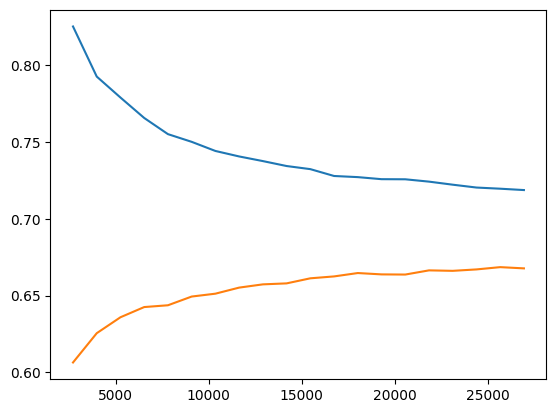

In [82]:
print(test_scores.mean(axis=1))
print(train_size_abs)
plt.plot(train_size_abs,train_scores.mean(axis=1))
plt.plot(train_size_abs, test_scores.mean(axis=1))


In [45]:
print(train_scores)

[[0.94010042 0.93675533 0.92720369 0.92504772 0.94959115 0.92673108
  0.92243346 0.9361213  0.93683341 0.94960365 0.94066918 0.93516148
  0.93163466 0.91443036 0.92472968 0.92618183 0.93136084 0.94331942
  0.92309369 0.93739476]
 [0.90314078 0.91987058 0.90557682 0.89666345 0.90723311 0.92569161
  0.89936828 0.90339192 0.89219881 0.91943863 0.90955688 0.9131603
  0.90222836 0.90002825 0.90062877 0.88558766 0.91529735 0.89407465
  0.8821491  0.92094487]
 [0.8816316  0.90493665 0.86805323 0.87889204 0.90621886 0.88862741
  0.89565921 0.89451323 0.86992274 0.89063475 0.87509216 0.88526835
  0.88326689 0.89638103 0.88203399 0.8782627  0.86860952 0.88825737
  0.86063654 0.90105575]
 [0.86506247 0.89083193 0.87376433 0.8560672  0.87550327 0.8704064
  0.86918621 0.87517057 0.84996509 0.87669626 0.86356901 0.86464583
  0.86826016 0.87029023 0.86451482 0.86102148 0.86450159 0.86085679
  0.84123555 0.89615909]
 [0.86671858 0.87014395 0.86643791 0.84277637 0.87673305 0.85244971
  0.86488804 0.861

In [34]:
rf_train_size_abs, rf_train_scores, rf_test_scores = learning_curve(RandomForestRegressor(), X, y.values.flatten(), shuffle = True, train_sizes=np.linspace(0.1, 1, 20), cv=5)

KeyboardInterrupt: 

In [40]:
scores = cross_validate(RandomForestRegressor(), X_shuf, y_shuf.values.flatten(), scoring='r2', cv=20, return_train_score=True)


In [41]:
print(scores)

{'fit_time': array([16.45559502, 16.3590014 , 16.02556515, 16.08636284, 16.58832693,
       16.21248651, 16.03397703, 16.1254549 , 16.27528334, 16.32744575,
       16.04739928, 16.08081555, 16.09324455, 16.02825308, 16.03075075,
       15.85325956, 16.1027565 , 15.96395302, 15.8802855 , 16.10422325]), 'score_time': array([0.04408646, 0.0448668 , 0.04550409, 0.04409027, 0.04370904,
       0.04391098, 0.04511499, 0.04430962, 0.04478192, 0.04438877,
       0.04420185, 0.04439926, 0.04444551, 0.04414225, 0.04435349,
       0.04512787, 0.04425192, 0.04490089, 0.04455757, 0.0440042 ]), 'test_score': array([0.65514873, 0.64795333, 0.6681648 , 0.55478316, 0.63602563,
       0.63801441, 0.66960679, 0.67003893, 0.68137495, 0.63530808,
       0.68375668, 0.70475319, 0.6969158 , 0.69927286, 0.63928239,
       0.62458503, 0.61082119, 0.65532854, 0.66664941, 0.60950756]), 'train_score': array([0.94943441, 0.94938147, 0.94912941, 0.9498581 , 0.94954764,
       0.94912423, 0.94934063, 0.94878663, 0.94